In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

import yfinance as yf 
import matplotlib.pyplot as plt 
import pandas as pd 
from pandas.plotting import lag_plot
import numpy as np
import statsmodels.api as sm 

In [17]:
PERIOD = 'max'
LOOKBACK = 10000
INTERVAL = '1d'

if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

tickers = ["^GSPC", "USO", "SLV", "EURUSD=X", "GLD"]

def fetch_latest_data():
    # Download data
    data = yf.download(tickers, period=PERIOD, interval=INTERVAL)
    
    # Access the 'Close' prices
    df = data["Close"].copy()
    
    # Explicitly map the tickers to desired names to avoid ordering issues
    column_mapping = {
        '^GSPC': 'SPX',
        'GLD' : 'GLD',
        'USO' : 'USO',
        'SLV' : 'SLV',
        'EURUSD=X': 'EUR/USD'
    }
    
    # Rename using the mapping
    df = df.rename(columns=column_mapping)
    
    # Reorder columns to match your expected logic
    df = df[["SPX", "GLD", "USO", "SLV", "EUR/USD"]]
    
    df = df.dropna().reset_index()
    return df

df = fetch_latest_data()
df

[*********************100%***********************]  5 of 5 completed


Ticker,Date,SPX,GLD,USO,SLV,EUR/USD
0,2006-04-28,1310.609985,65.089996,556.960022,13.812000,1.263600
1,2006-05-01,1305.189941,65.160004,572.000000,13.870000,1.258004
2,2006-05-02,1313.209961,66.550003,578.719971,14.365000,1.261702
3,2006-05-03,1308.119995,66.459999,561.760010,13.925000,1.262307
4,2006-05-04,1312.250000,67.480003,546.559998,14.000000,1.270099
...,...,...,...,...,...,...
5072,2026-08-07,7757.640137,398.470001,117.980003,57.500000,1.152472
5073,2026-08-10,7753.109863,402.540009,125.919998,59.410000,1.155642
5074,2026-08-11,7728.200195,400.959991,127.610001,58.549999,1.154641
5075,2026-08-12,7748.500000,404.920013,127.300003,59.060001,1.154374


In [18]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (5077, 6)

Dtypes:
float64           5
datetime64[ns]    1
Name: count, dtype: int64


In [19]:
df.describe(include='all').T.head(20)

,count,mean,min,25%,50%,75%,max,std
Ticker,,,,,,,,
Date,5077,2016-06-29 23:00:43.253890048,2006-04-28 00:00:00,2011-06-14 00:00:00,2016-07-01 00:00:00,2021-07-22 00:00:00,2026-08-13 00:00:00,NaN
SPX,5077.0,2767.56922,676.530029,1399.47998,2124.290039,3919.290039,7798.990234,1673.745201
GLD,5077.0,151.382379,55.619999,114.099998,128.679993,169.619995,495.899994,73.483976
USO,5077.0,199.209992,17.040001,75.68,112.800003,292.079987,939.840027,165.73829
SLV,5077.0,21.793389,8.85,15.32,18.32,24.860001,105.599998,11.109798
EUR/USD,5077.0,1.221379,0.959619,1.112446,1.181401,1.326418,1.598798,0.132275


In [20]:
print('Duplicates:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 0
Memory (MB): 0.23


In [21]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No missing values')

No missing values


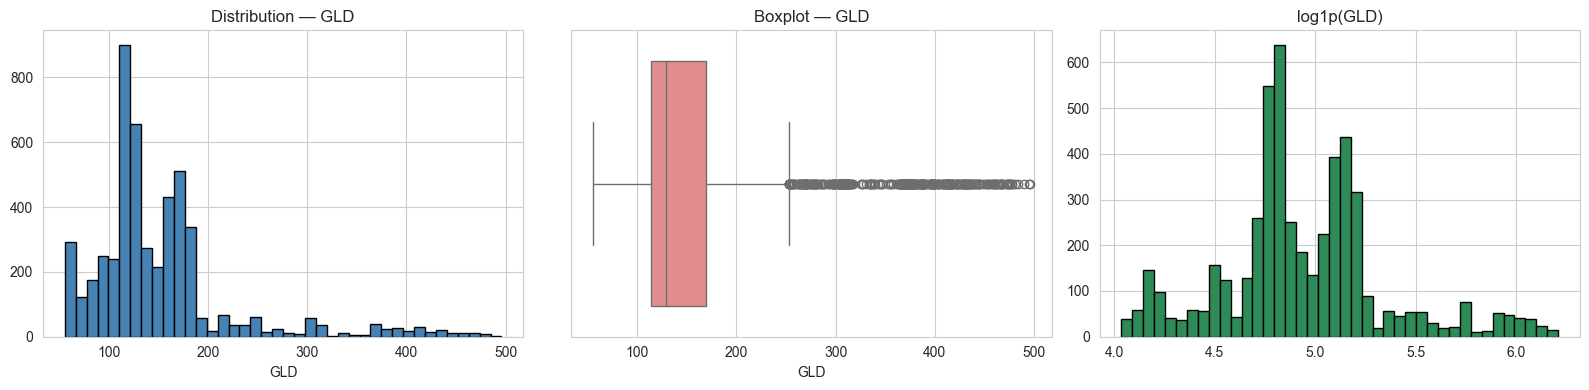

Skewness : 2.098
Kurtosis : 5.173
count    5077.00
mean      151.38
std        73.48
min        55.62
25%       114.10
50%       128.68
75%       169.62
max       495.90
Name: GLD, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['GLD'].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution — GLD')
axes[0].set_xlabel('GLD')
sns.boxplot(x=df['GLD'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — GLD')
# Log scale (skewed targets)
axes[2].hist(np.log1p(df['GLD'].dropna()), bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('log1p(GLD)')
plt.tight_layout(); plt.show()
print('Skewness :', round(df['GLD'].skew(), 3))
print('Kurtosis :', round(df['GLD'].kurtosis(), 3))
print(df['GLD'].describe().round(2))

In [23]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'GLD' in numeric_cols:
    numeric_cols.remove('GLD')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols[:30])

Numeric features (4):
['SPX', 'USO', 'SLV', 'EUR/USD']


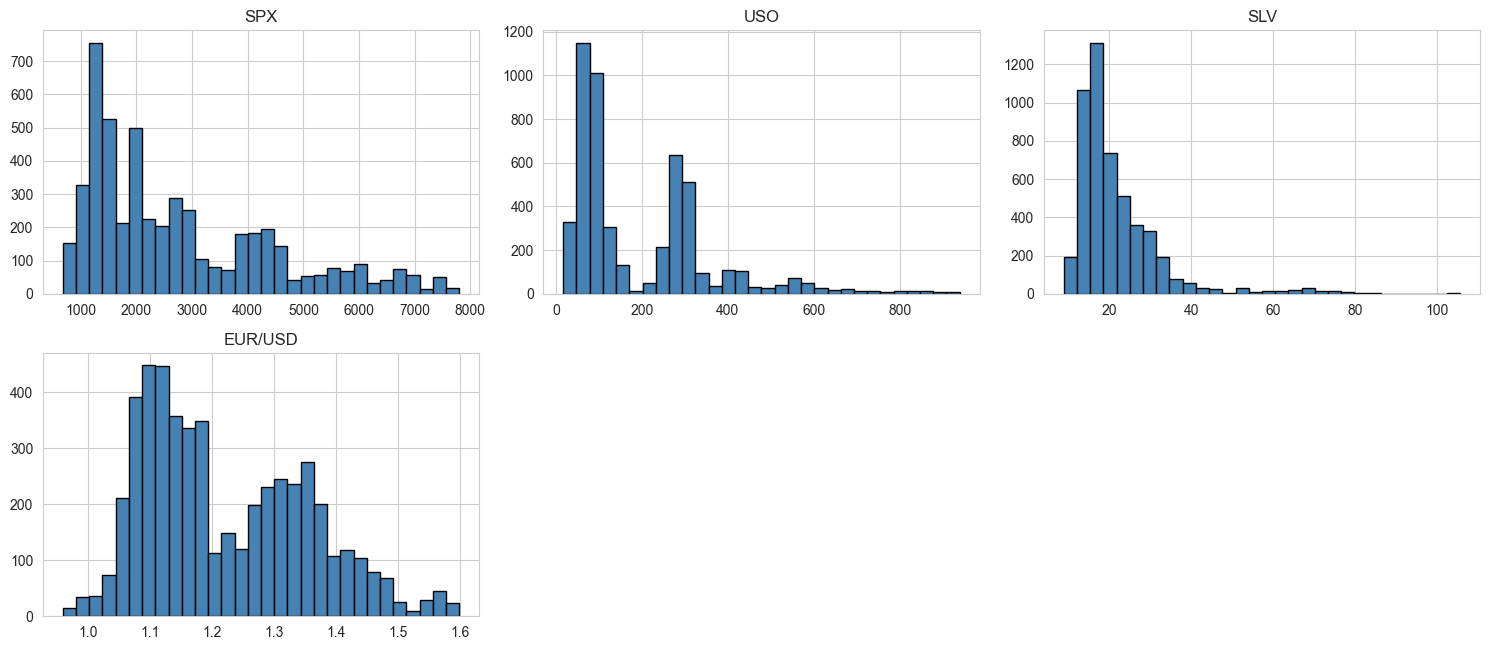

In [24]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

In [25]:
corrs_all = df[numeric_cols + ['GLD']].corr()['GLD'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'GLD'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Ticker
SLV        0.878
SPX        0.854
USO        0.461
EUR/USD    0.366
Name: GLD, dtype: float64


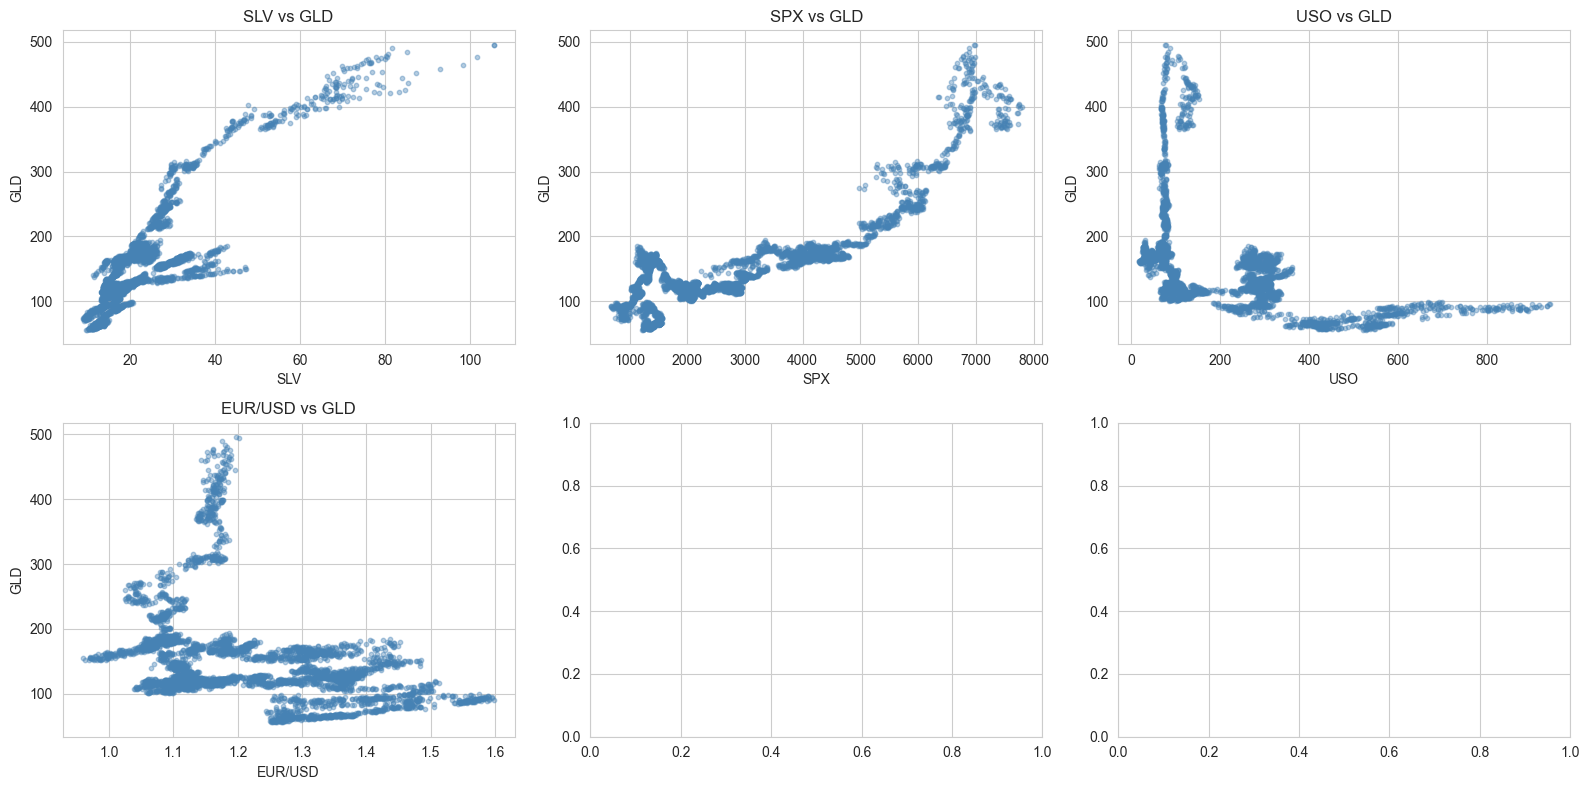

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top_features[:6]):
    axes[i].scatter(df[col], df['GLD'], alpha=0.4, s=10, color='steelblue')
    axes[i].set_xlabel(col); axes[i].set_ylabel('GLD')
    axes[i].set_title(f'{col} vs GLD')
plt.tight_layout(); plt.show()

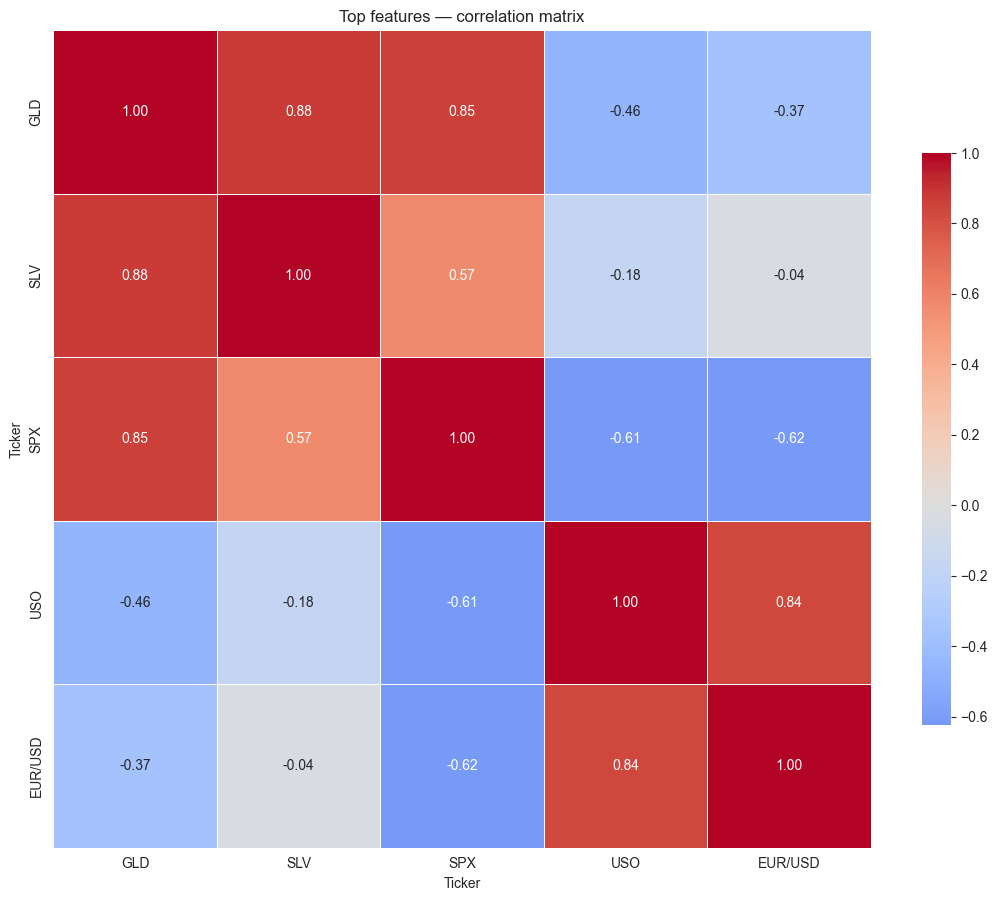

In [27]:
top_numeric = corrs_all.head(15).index.tolist()
if 'GLD' not in top_numeric:
    top_numeric.append('GLD')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

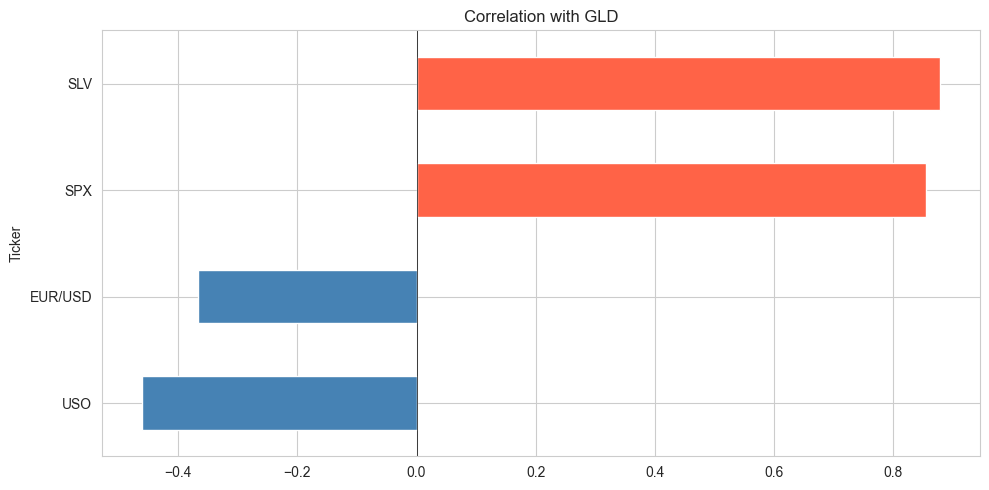

In [28]:
target_corr = df[numeric_cols + ['GLD']].corr()['GLD'].drop('GLD').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with GLD')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

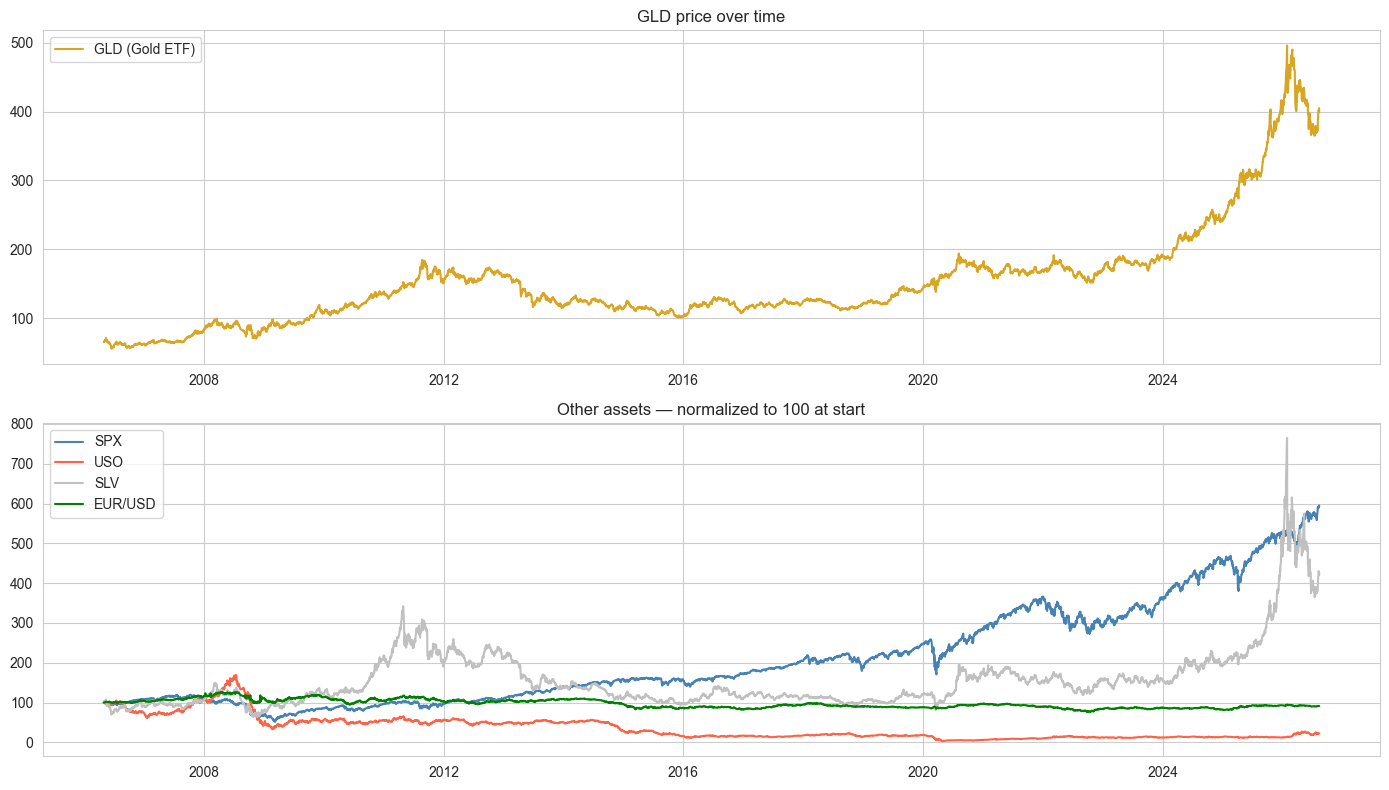

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df['Date'], df['GLD'], color='goldenrod', label='GLD (Gold ETF)')
axes[0].set_title('GLD price over time'); axes[0].legend()
for col, c in [('SPX', 'steelblue'), ('USO', 'tomato'), ('SLV', 'silver'), ('EUR/USD', 'green')]:
    if col in df.columns:
        axes[1].plot(df['Date'], df[col]/df[col].iloc[0]*100, label=col, color=c)
axes[1].set_title('Other assets — normalized to 100 at start')
axes[1].legend(); plt.tight_layout(); plt.show()

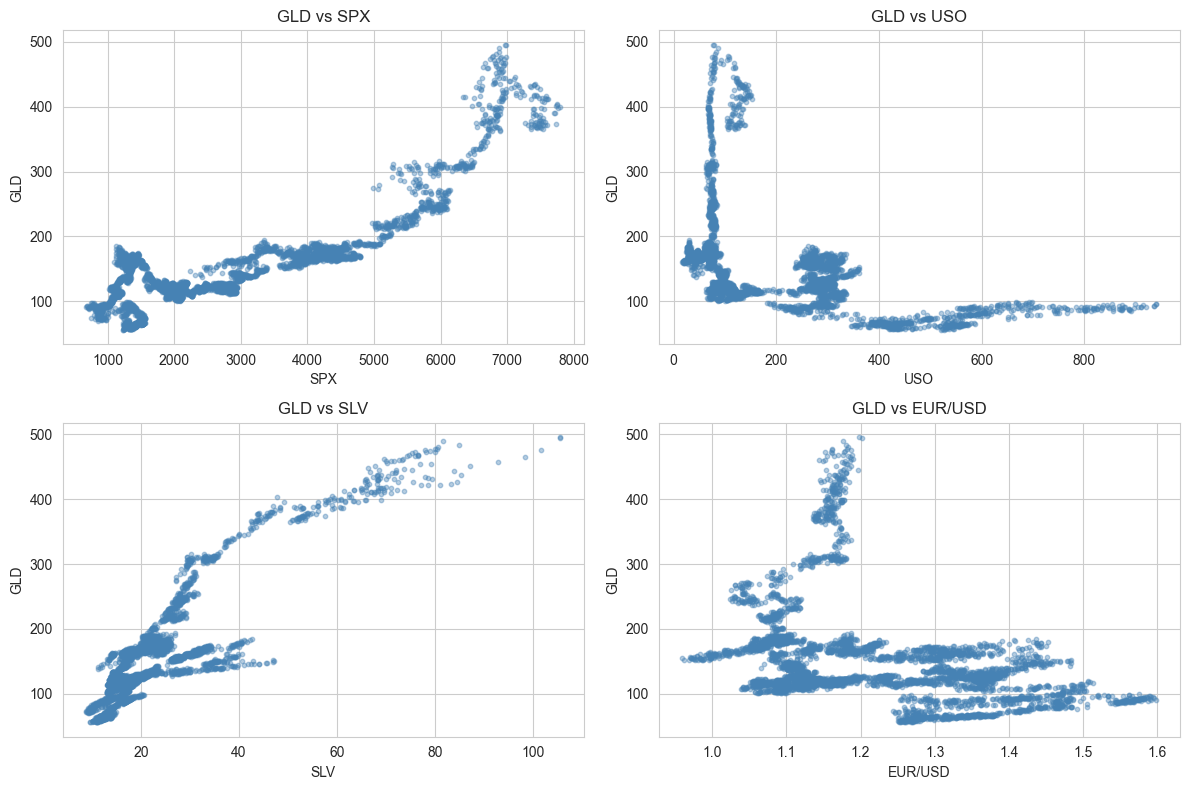

In [30]:
# Scatter: GLD vs each other asset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, ['SPX', 'USO', 'SLV', 'EUR/USD']):
    if col in df.columns:
        ax.scatter(df[col], df['GLD'], alpha=0.4, s=10, color='steelblue')
        ax.set_xlabel(col); ax.set_ylabel('GLD')
        ax.set_title(f'GLD vs {col}')
plt.tight_layout(); plt.show()

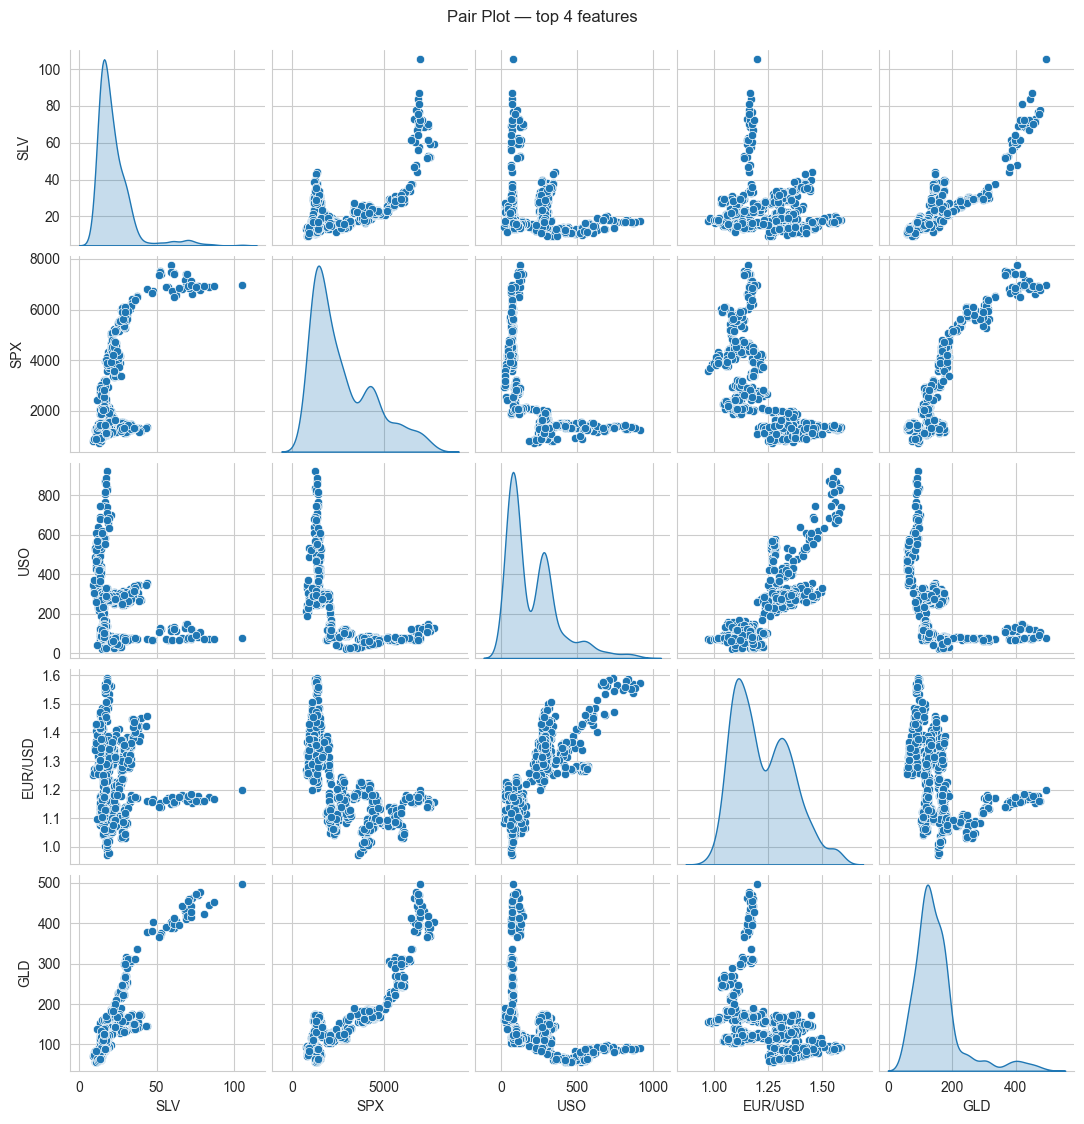

In [31]:
sample = df.sample(min(800, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['GLD']].dropna(), diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

In [32]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df['GLD'].mean(), 2),
        round(df['GLD'].median(), 2),
        round(df['GLD'].std(), 2),
        round(df['GLD'].min(), 2),
        round(df['GLD'].max(), 2),
        round(df['GLD'].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,5077
1,Total features,5
2,Target mean,151.38
3,Target median,128.68
4,Target stddev,73.48
5,Target min,55.62
6,Target max,495.9
7,Target skewness,2.098
8,Top correlated feature,SLV
9,Top correlation value,0.878


In [33]:
print('Missing values:', df.isnull().sum().sum())
print('Date range:', df['Date'].min(), '->', df['Date'].max())
df_clean = df.copy()

Missing values: 0
Date range: 2006-04-28 00:00:00 -> 2026-08-13 00:00:00


In [34]:
df_imputed = df_clean.copy()
print('NaN count:', df_imputed.isnull().sum().sum())

NaN count: 0


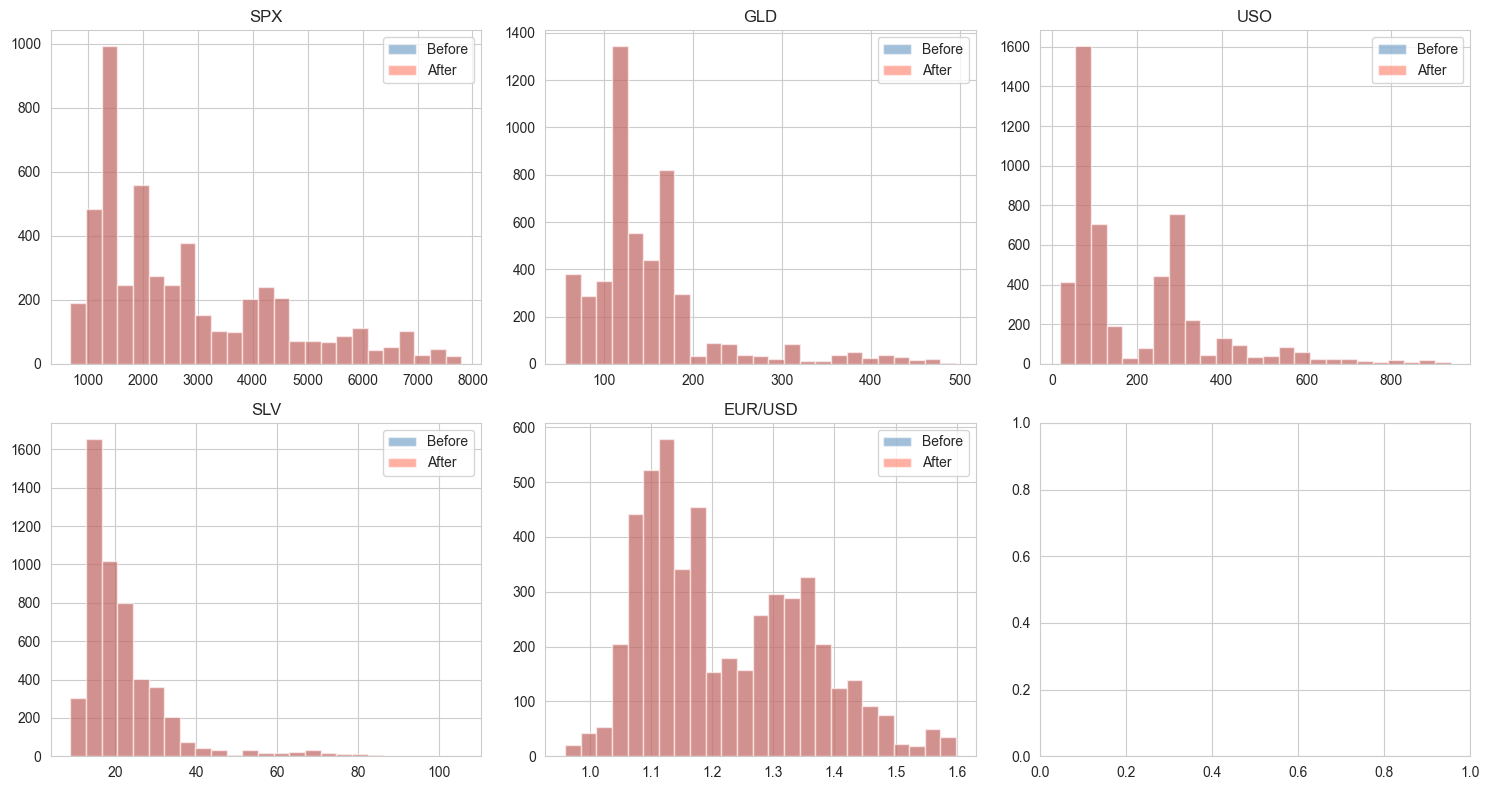

In [35]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [36]:
def create_features(df):
    """Engineer rolling means, diffs, and date-based features."""
    df = df.copy()

    if "Date" in df.columns:
        df["Year"] = df["Date"].dt.year
        df["Month"] = df["Date"].dt.month
        df["DayOfWeek"] = df["Date"].dt.dayofweek

    for col in ["SPX", "USO", "SLV", "EUR/USD"]:
        if col in df.columns:
            df[f"{col}_roll5"] = df[col].rolling(5, min_periods=1).mean()
            df[f"{col}_diff"] = df[col].diff().fillna(0)

    # Spread of related precious-metal / oil ETFs
    if {"SLV", "USO"}.issubset(df.columns):
        df["SLV_USO_ratio"] = df["SLV"] / df["USO"].replace(0, np.nan)

    # Drop the date column (replaced by year/month/dow)
    if "Date" in df.columns:
        df = df.drop(columns=["Date"])

    df = df.fillna(method="bfill").fillna(0)
    return df

In [37]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (5077, 17)


Ticker,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1310.609985,65.089996,556.960022,13.812,1.263600,2006,4,4,1310.609985,0.000000,556.960022,0.000000,13.812000,0.000,1.263600,0.000000,0.024799
1,1305.189941,65.160004,572.000000,13.870,1.258004,2006,5,0,1307.899963,-5.420044,564.480011,15.039978,13.841000,0.058,1.260802,-0.005595,0.024248
2,1313.209961,66.550003,578.719971,14.365,1.261702,2006,5,1,1309.669963,8.020020,569.226664,6.719971,14.015667,0.495,1.261102,0.003698,0.024822
3,1308.119995,66.459999,561.760010,13.925,1.262307,2006,5,2,1309.282471,-5.089966,567.360001,-16.959961,13.993000,-0.440,1.261403,0.000605,0.024788
4,1312.250000,67.480003,546.559998,14.000,1.270099,2006,5,3,1309.875977,4.130005,563.200000,-15.200012,13.994400,0.075,1.263143,0.007792,0.025615


In [38]:
def preprocess_data(df):
    df = create_features(df)
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(int)
    return df

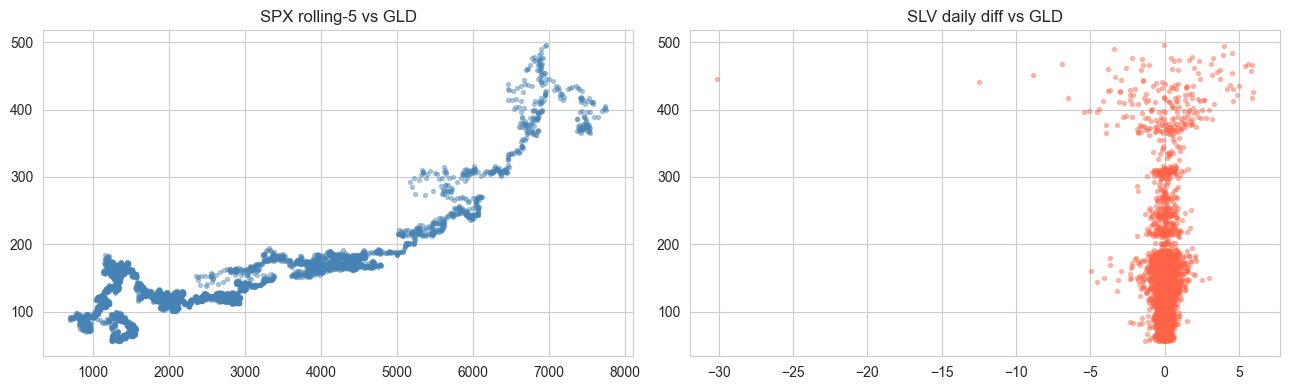

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if 'SPX_roll5' in df_feat.columns:
    axes[0].scatter(df_feat['SPX_roll5'], df_feat['GLD'], alpha=0.4, s=8, color='steelblue')
    axes[0].set_title('SPX rolling-5 vs GLD')
if 'SLV_diff' in df_feat.columns:
    axes[1].scatter(df_feat['SLV_diff'], df_feat['GLD'], alpha=0.4, s=8, color='tomato')
    axes[1].set_title('SLV daily diff vs GLD')
plt.tight_layout(); plt.show()

In [40]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Final shape:', df_encoded.shape)

Categorical columns: []
Final shape: (5077, 17)


In [42]:
df_encoded.head()

Ticker,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1310.609985,65.089996,556.960022,13.812,1.263600,2006,4,4,1310.609985,0.000000,556.960022,0.000000,13.812000,0.000,1.263600,0.000000,0.024799
1,1305.189941,65.160004,572.000000,13.870,1.258004,2006,5,0,1307.899963,-5.420044,564.480011,15.039978,13.841000,0.058,1.260802,-0.005595,0.024248
2,1313.209961,66.550003,578.719971,14.365,1.261702,2006,5,1,1309.669963,8.020020,569.226664,6.719971,14.015667,0.495,1.261102,0.003698,0.024822
3,1308.119995,66.459999,561.760010,13.925,1.262307,2006,5,2,1309.282471,-5.089966,567.360001,-16.959961,13.993000,-0.440,1.261403,0.000605,0.024788
4,1312.250000,67.480003,546.559998,14.000,1.270099,2006,5,3,1309.875977,4.130005,563.200000,-15.200012,13.994400,0.075,1.263143,0.007792,0.025615


In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import cross_val_score

In [45]:
def evaluate_model(model_name, y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    metrics = {
        "Model": model_name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse,
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(mean_absolute_percentage_error(y_true, y_pred)),
    }
    print(f"\n{'='*40}\n  {model_name}\n{'='*40}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k:6s}: {v:.4f}")
    return metrics

In [46]:
def plot_pred_vs_actual(y_true, y_pred, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, color="steelblue")
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.plot([lo, hi], [lo, hi], "r--", label="perfect")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(f"Predicted vs Actual — {model_name}"); ax.legend()
    return ax

In [47]:
def plot_residuals(y_true, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    residuals = np.array(y_true) - np.array(y_pred)
    axes[0].scatter(y_pred, residuals, alpha=0.4, s=15, color="steelblue")
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
    axes[0].set_title(f"Residuals vs Predicted — {model_name}")
    axes[1].hist(residuals, bins=40, color="seagreen", edgecolor="black")
    axes[1].set_xlabel("Residual"); axes[1].set_title("Residual distribution")
    plt.tight_layout()
    return fig

In [48]:
def cross_validate_model(model, X, y, cv=5):
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    print(f"  CV R² Scores : {scores.round(4)}")
    print(f"  Mean R²      : {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores

In [49]:
def compare_models(results_list):
    df_results = pd.DataFrame(results_list)
    return df_results.sort_values("R2", ascending=False).reset_index(drop=True)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [52]:
df = df_encoded 
print('Shape:', df.shape)
df.head()

Shape: (5077, 17)


Ticker,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1310.609985,65.089996,556.960022,13.812,1.263600,2006,4,4,1310.609985,0.000000,556.960022,0.000000,13.812000,0.000,1.263600,0.000000,0.024799
1,1305.189941,65.160004,572.000000,13.870,1.258004,2006,5,0,1307.899963,-5.420044,564.480011,15.039978,13.841000,0.058,1.260802,-0.005595,0.024248
2,1313.209961,66.550003,578.719971,14.365,1.261702,2006,5,1,1309.669963,8.020020,569.226664,6.719971,14.015667,0.495,1.261102,0.003698,0.024822
3,1308.119995,66.459999,561.760010,13.925,1.262307,2006,5,2,1309.282471,-5.089966,567.360001,-16.959961,13.993000,-0.440,1.261403,0.000605,0.024788
4,1312.250000,67.480003,546.559998,14.000,1.270099,2006,5,3,1309.875977,4.130005,563.200000,-15.200012,13.994400,0.075,1.263143,0.007792,0.025615


In [53]:
X = df.drop(columns=['GLD'])
y = df['GLD']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 16
Target stats:
count    5077.00
mean      151.38
std        73.48
min        55.62
25%       114.10
50%       128.68
75%       169.62
max       495.90
Name: GLD, dtype: float64
Train: (4061, 16) Test: (1016, 16)


In [54]:
results = []
models = {}


  Linear Regression
  MAE   : 11.0801
  RMSE  : 15.5324
  R2    : 0.9593
  MAPE  : 0.0790


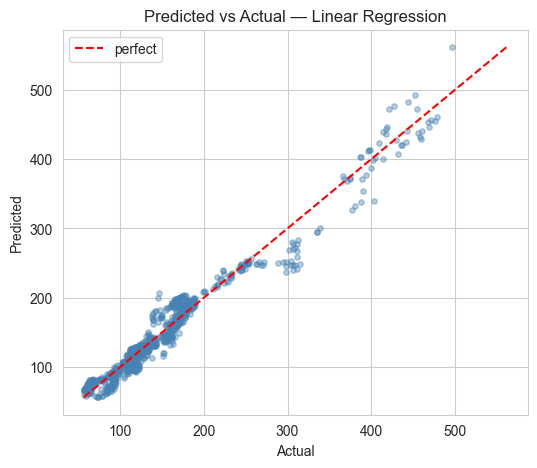

In [55]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()


  Ridge
  MAE   : 11.0865
  RMSE  : 15.5360
  R2    : 0.9593
  MAPE  : 0.0790


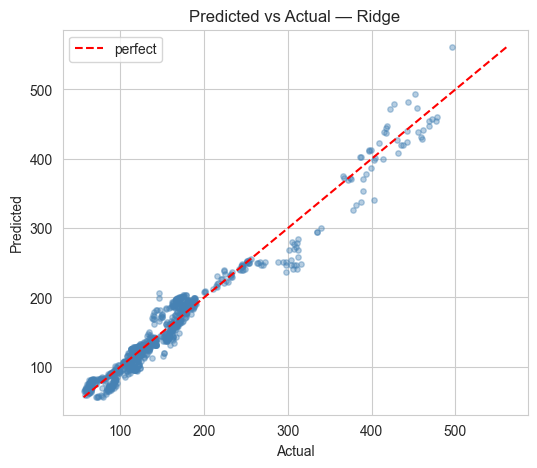

In [56]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()


  Lasso
  MAE   : 11.1135
  RMSE  : 15.5264
  R2    : 0.9593
  MAPE  : 0.0798


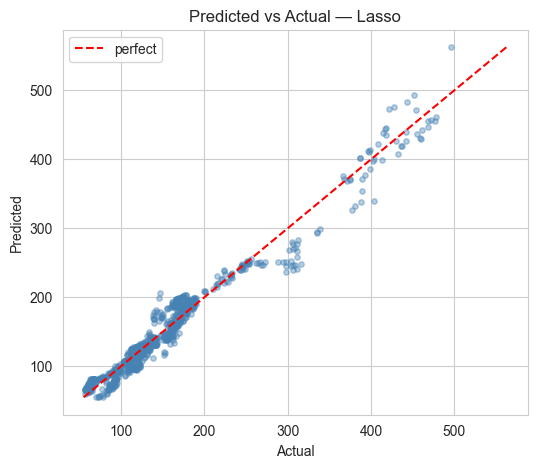

In [57]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()


  Decision Tree
  MAE   : 2.2359
  RMSE  : 3.7049
  R2    : 0.9977
  MAPE  : 0.0151


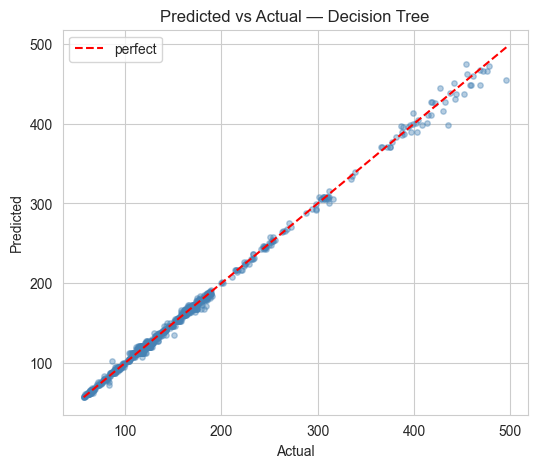

In [58]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()


  Random Forest
  MAE   : 1.4427
  RMSE  : 3.0306
  R2    : 0.9985
  MAPE  : 0.0085


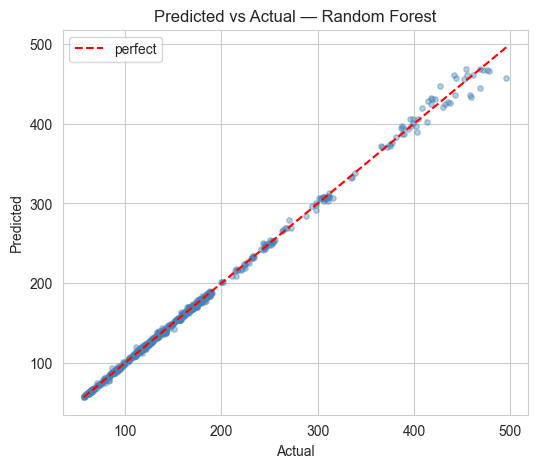

In [59]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()

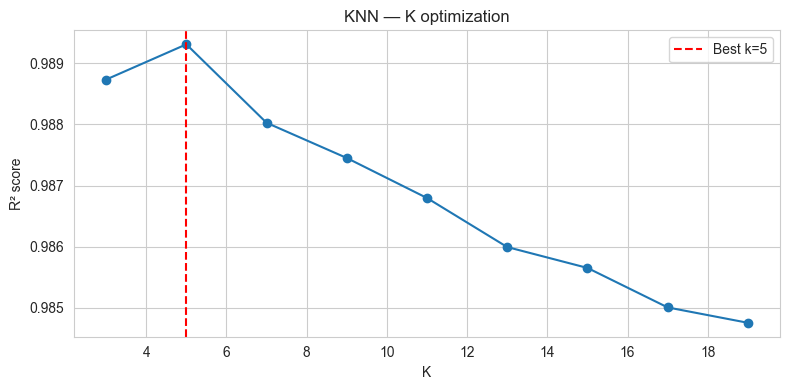


  KNN (k=5)
  MAE   : 4.8829
  RMSE  : 7.9607
  R2    : 0.9893
  MAPE  : 0.0313


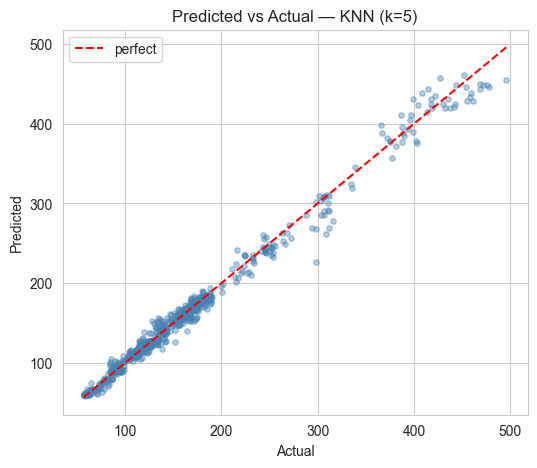

In [60]:
k_range = range(3, 21, 2)
from sklearn.metrics import r2_score
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4)); plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, knn_label); plt.show()


  Gradient Boosting
  MAE   : 2.4993
  RMSE  : 3.7722
  R2    : 0.9976
  MAPE  : 0.0168


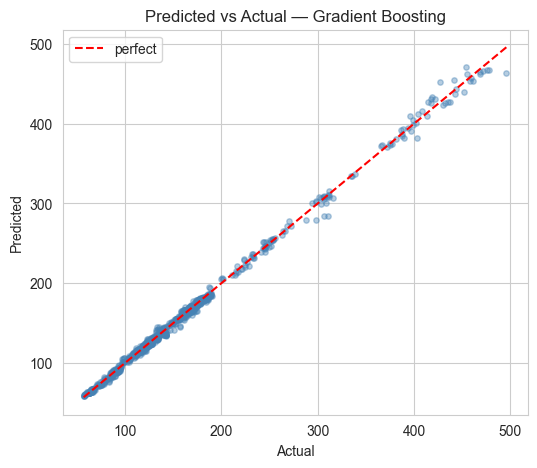

In [61]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting'); plt.show()

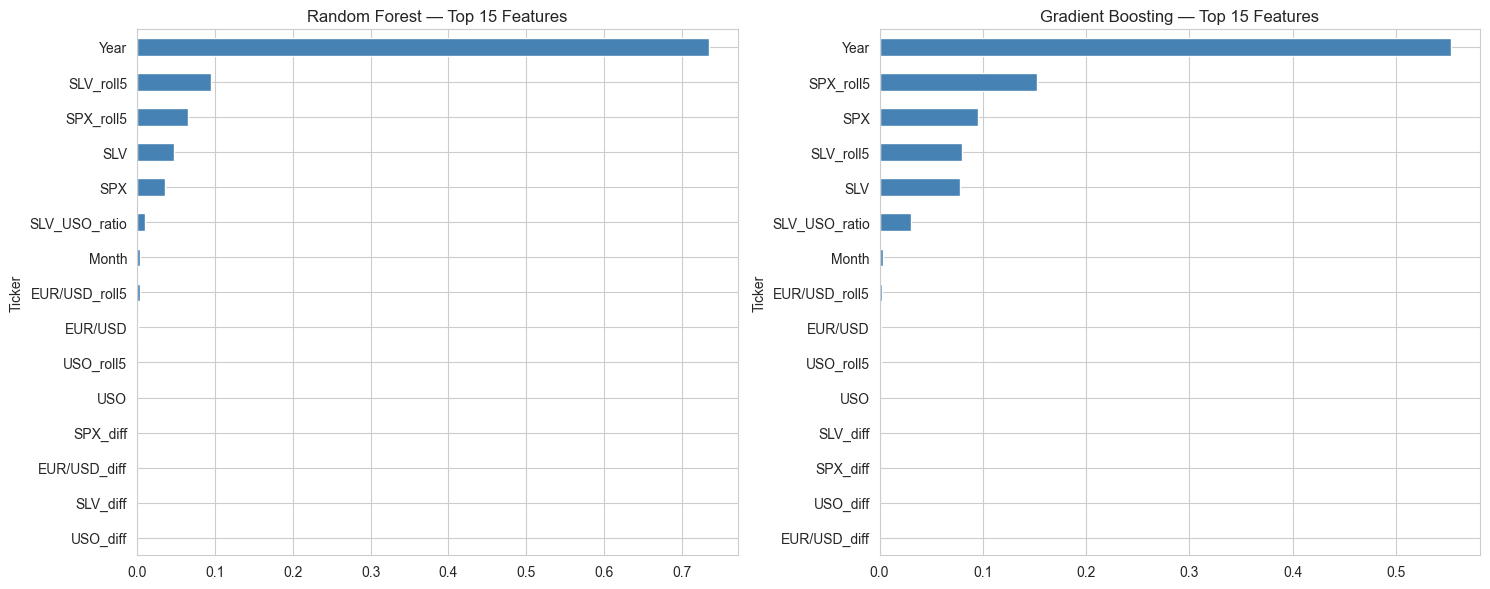

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()

In [63]:
comparison = compare_models(results)
comparison

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,1.442686,3.030583,0.998450,0.008511
1,Decision Tree,2.235927,3.704893,0.997684,0.015110
2,Gradient Boosting,2.499322,3.772159,0.997599,0.016799
3,KNN (k=5),4.882907,7.960747,0.989308,0.031263
4,Lasso,11.113474,15.526378,0.959327,0.079803
5,Linear Regression,11.080055,15.532415,0.959295,0.078961
6,Ridge,11.086462,15.535964,0.959277,0.079048


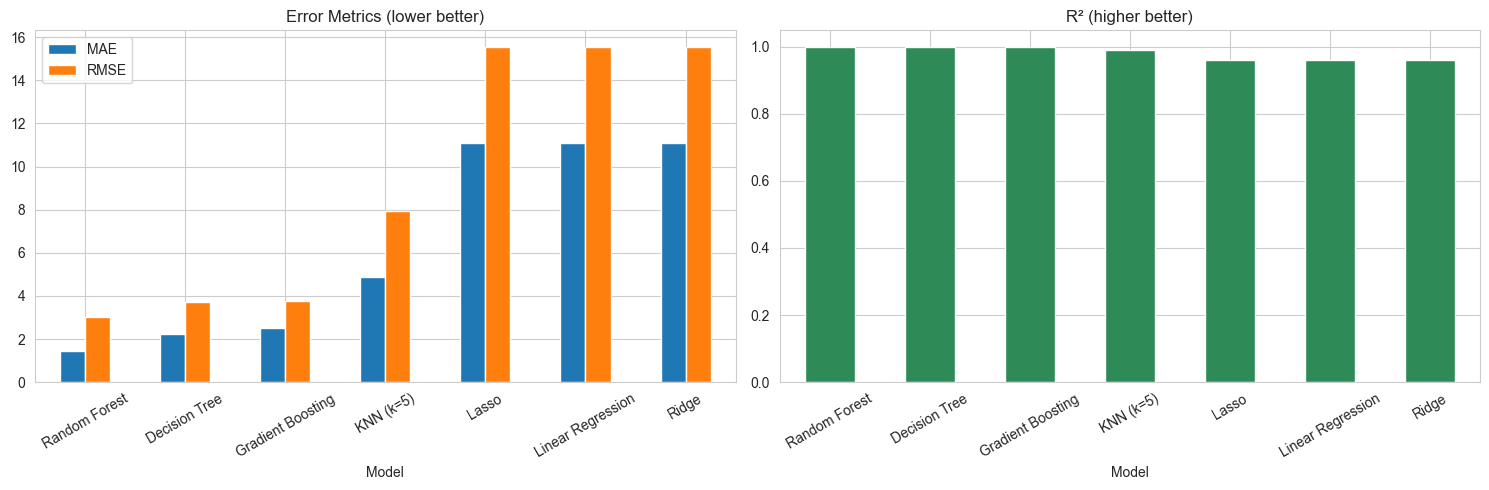

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

In [65]:
cv_scores = {}
X_full_scaled = scaler.fit_transform(X)
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='r2', n_jobs=-1)
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear Regression         mean R² = -0.6827 (+/- 1.8446)
Ridge                     mean R² = -0.6727 (+/- 1.8266)
Lasso                     mean R² = -0.3356 (+/- 1.2288)
Decision Tree             mean R² = -10.2219 (+/- 16.8946)
Random Forest             mean R² = -3.9092 (+/- 4.1449)
KNN (k=5)                 mean R² = -1.9269 (+/- 2.0629)
Gradient Boosting         mean R² = -1.7107 (+/- 2.2433)


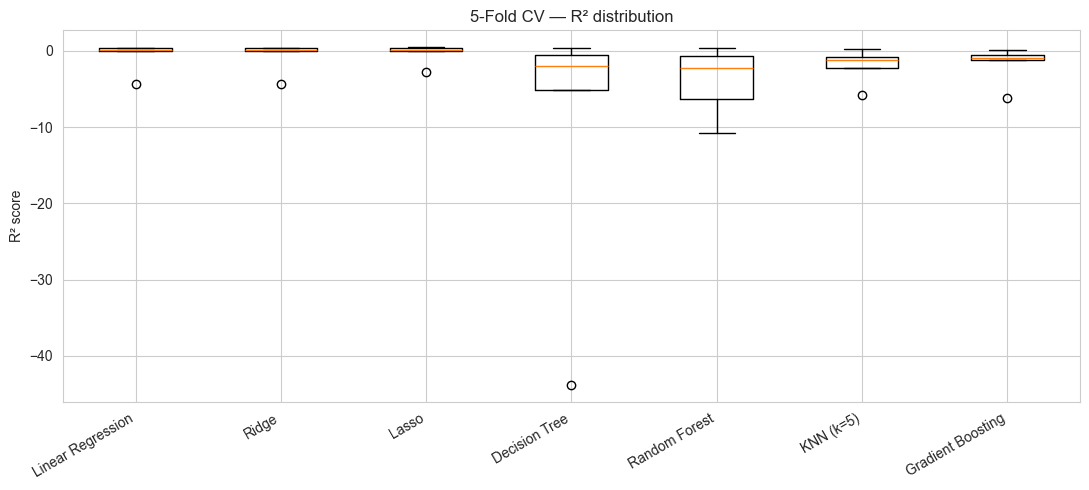

In [66]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('5-Fold CV — R² distribution'); plt.tight_layout(); plt.show()

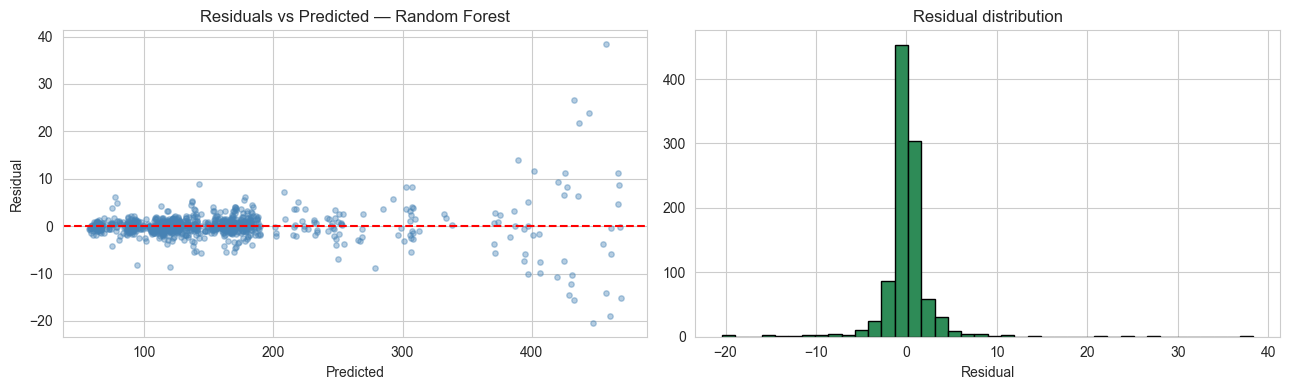

In [67]:
best_model_name = comparison.iloc[0]['Model']
kind, best_pre = models[best_model_name]
Xt = X_test_scaled if kind == 'scaled' else X_test
y_pred_best = best_pre.predict(Xt)
plot_residuals(y_test, y_pred_best, best_model_name); plt.show()

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV R²: 0.9985
Model saved as best_rf_model_2.pkl

  Random Forest (Tuned)
  MAE   : 1.4373
  RMSE  : 3.0120
  R2    : 0.9985
  MAPE  : 0.0085


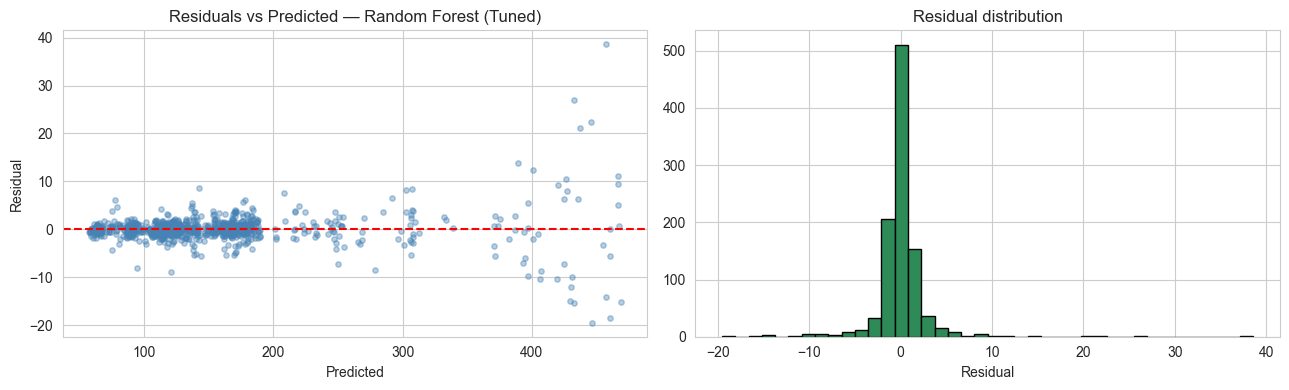

In [74]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
}
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_

import joblib

joblib.dump(best, "best_rf_model_2.pkl")
print("Model saved as best_rf_model_2.pkl")

y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Random Forest (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Random Forest (Tuned)'); plt.show()

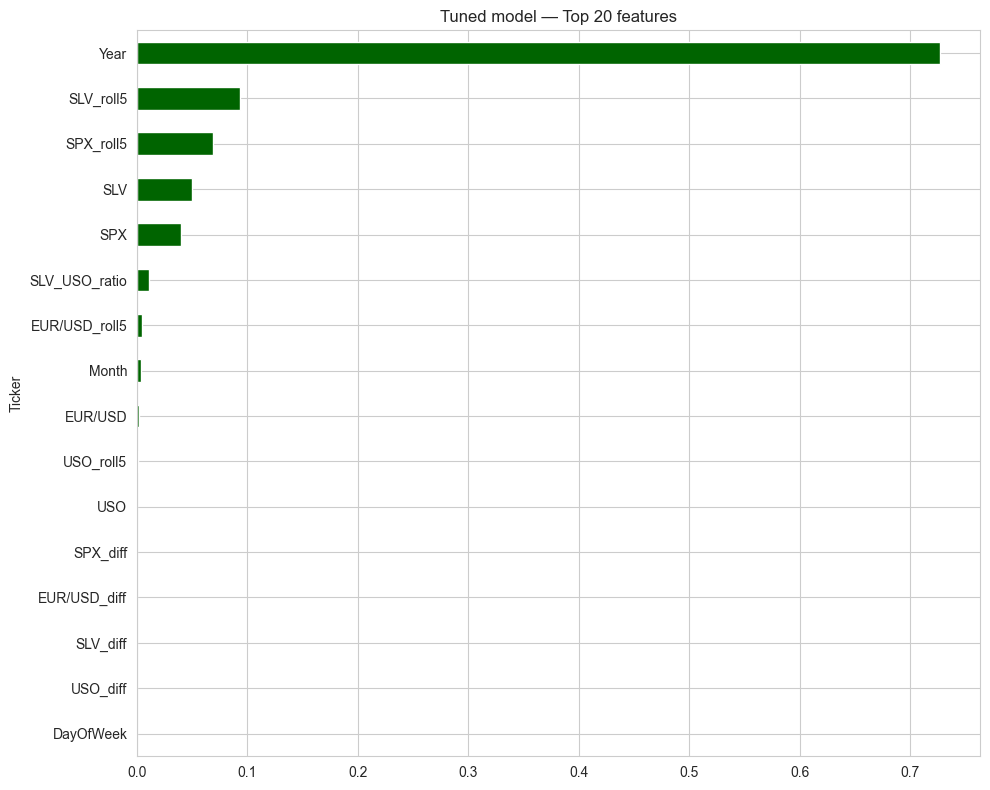

In [75]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()

In [76]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out

,Predicted,Actual,AbsError
0,108.13,109.76,1.63
1,247.04,245.00,2.04
2,57.74,57.32,0.42
3,122.14,121.98,0.16
4,178.70,179.22,0.52


In [77]:
final = compare_models(results)
final

,Model,MAE,RMSE,R2,MAPE
0,Random Forest (Tuned),1.437255,3.011978,0.998469,0.008486
1,Random Forest (Tuned),1.437255,3.011978,0.998469,0.008486
2,Random Forest,1.442686,3.030583,0.998450,0.008511
3,Decision Tree,2.235927,3.704893,0.997684,0.015110
4,Gradient Boosting,2.499322,3.772159,0.997599,0.016799
5,KNN (k=5),4.882907,7.960747,0.989308,0.031263
6,Lasso,11.113474,15.526378,0.959327,0.079803
7,Linear Regression,11.080055,15.532415,0.959295,0.078961
8,Ridge,11.086462,15.535964,0.959277,0.079048


In [78]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

tickers = ["^GSPC", "USO", "SLV", "EURUSD=X"]

def create_features(df):
    df = df.copy()

    # Date-based features
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["DayOfWeek"] = df["Date"].dt.dayofweek

    # Rolling + diff features
    for col in ["SPX", "USO", "SLV", "EUR/USD"]:
        df[f"{col}_roll5"] = df[col].rolling(5, min_periods=1).mean()
        df[f"{col}_diff"] = df[col].diff().fillna(0)

    # Ratio feature
    df["SLV_USO_ratio"] = df["SLV"] / df["USO"].replace(0, np.nan)

    df = df.fillna(method="bfill").fillna(0)
    return df

def fetch_latest_data():
    # Download data
    data = yf.download(tickers, period="7d", interval="1d")
    
    # Access the 'Close' prices
    df = data["Close"].copy()
    
    # Explicitly map the tickers to desired names to avoid ordering issues
    column_mapping = {
        '^GSPC': 'SPX',
        'USO': 'USO',
        'SLV': 'SLV',
        'EURUSD=X': 'EUR/USD'
    }
    
    # Rename using the mapping
    df = df.rename(columns=column_mapping)
    
    # Reorder columns to match your expected logic
    df = df[["SPX", "USO", "SLV", "EUR/USD"]]
    
    df = df.dropna().reset_index()
    return df

# Fetch today's data
df_today = fetch_latest_data()

# Apply feature engineering
df_feat_today = create_features(df_today)

# Prepare today's feature row
X_today = df_feat_today.drop(columns=["Date"]).iloc[-1:].copy()

# Load model
best_model = joblib.load(r"c:\Users\aadam\Desktop\Algorithmic Trading\Practice Projects\best_rf_model_2.pkl")

# Predict tomorrow's GLD price
predicted_gld = best_model.predict(X_today)[0]
print(f"Predicted GLD price for tomorrow: {predicted_gld:.2f}")


[*********************100%***********************]  4 of 4 completed


Predicted GLD price for tomorrow: 397.34
